# 📱 SMS Scam Classification — Multi-Model Comparison

**Task:** Multi-class text classification of SMS messages into 6 categories:
- `benign` — normal messages
- `kyc_scam` — KYC fraud attempts
- `impersonation` — sender impersonation
- `phishing_link` — phishing links
- `fake_payment_portal` — fake payment sites
- `account_block_scam` — account blocking threats

**Models compared:**
1. Logistic Regression (TF-IDF)
2. Multinomial Naive Bayes (TF-IDF)
3. Linear SVM (TF-IDF)
4. Random Forest (TF-IDF)
5. Gradient Boosting (TF-IDF)


## 1. 📦 Install & Import Libraries

In [1]:
# Install required libraries (run once)
# !pip install scikit-learn pandas numpy matplotlib seaborn xgboost

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Text processing
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# Timing
import time

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


## 2. 📂 Load Data

In [3]:
# -------------------------------------------------------
# Update these paths if your CSV files are elsewhere
# -------------------------------------------------------
TRAIN_PATH = '/Users/bhavyakansal/Datasets/train.csv'
TEST_PATH  = '/Users/bhavyakansal/Datasets/test.csv'

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

print(f'Train shape : {train_df.shape}')
print(f'Test  shape : {test_df.shape}')
train_df.head()

Train shape : (7000, 2)
Test  shape : (3000, 2)


,message_text,class_label
0,New water meter installation scheduled at your...,benign
1,Your water account 5774836158 has no pending d...,benign
2,BOI Security: Transaction of Rs.2135 from acco...,impersonation
3,BWSSB Notice: Pending water bill Rs.20462 for ...,kyc_scam
4,KYC expired. Update within 2 hours to avoid ac...,phishing_link


## 3. 🔍 Exploratory Data Analysis (EDA)

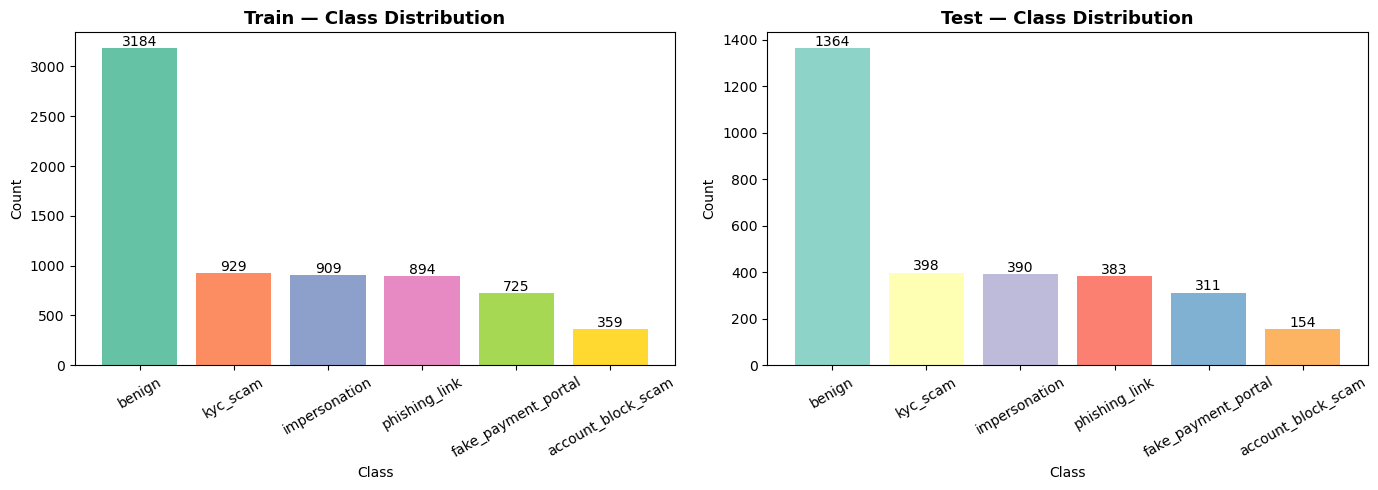

In [4]:
# Class distribution in train set
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train
train_counts = train_df['class_label'].value_counts()
axes[0].bar(train_counts.index, train_counts.values,
            color=sns.color_palette('Set2', len(train_counts)))
axes[0].set_title('Train — Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(train_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontsize=10)

# Test
test_counts = test_df['class_label'].value_counts()
axes[1].bar(test_counts.index, test_counts.values,
            color=sns.color_palette('Set3', len(test_counts)))
axes[1].set_title('Test — Class Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(test_counts.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

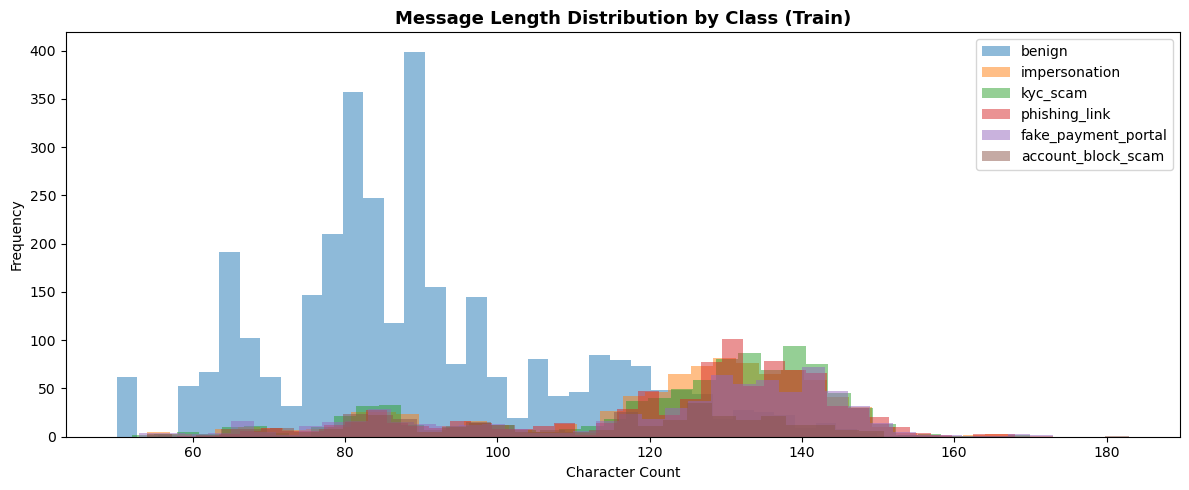

                      count   mean   std   min    25%    50%    75%    max
class_label                                                               
account_block_scam    359.0  109.5  24.5  54.0   87.0  117.0  129.0  183.0
benign               3184.0   89.2  19.4  50.0   78.0   87.0   98.0  158.0
fake_payment_portal   725.0  120.9  24.9  53.0  104.0  129.0  139.0  173.0
impersonation         909.0  121.9  22.4  54.0  116.0  128.0  137.0  173.0
kyc_scam              929.0  122.4  22.9  52.0  115.0  130.0  139.0  170.0
phishing_link         894.0  123.9  21.1  58.0  117.0  130.0  138.0  168.0


In [5]:
# Message length analysis
train_df['msg_length'] = train_df['message_text'].str.len()
test_df['msg_length']  = test_df['message_text'].str.len()

fig, ax = plt.subplots(figsize=(12, 5))
for label in train_df['class_label'].unique():
    subset = train_df[train_df['class_label'] == label]['msg_length']
    ax.hist(subset, bins=40, alpha=0.5, label=label)

ax.set_title('Message Length Distribution by Class (Train)', fontsize=13, fontweight='bold')
ax.set_xlabel('Character Count')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig('message_length.png', dpi=150, bbox_inches='tight')
plt.show()

print(train_df.groupby('class_label')['msg_length']
      .describe().round(1).to_string())

## 4. 🔧 Preprocessing & Feature Extraction

In [6]:
import re

def clean_text(text):
    """Basic text cleaning — lowercase, remove URLs, numbers, extra spaces."""
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', ' url ', text)   # URLs
    text = re.sub(r'\b\d{6,}\b', ' NUM ', text)         # long numbers (account/OTP)
    text = re.sub(r'[^a-z\s]', ' ', text)               # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply cleaning
X_train_raw = train_df['message_text'].apply(clean_text)
X_test_raw  = test_df['message_text'].apply(clean_text)

# Encode labels
le = LabelEncoder()
y_train = le.fit_transform(train_df['class_label'])
y_test  = le.transform(test_df['class_label'])

print('Classes:', list(le.classes_))

# TF-IDF vectoriser — fit ONLY on train
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),  # unigrams + bigrams
    max_features=20_000,
    sublinear_tf=True,
    min_df=2
)
X_train = tfidf.fit_transform(X_train_raw)
X_test  = tfidf.transform(X_test_raw)

print(f'Train matrix : {X_train.shape}')
print(f'Test  matrix : {X_test.shape}')

Classes: ['account_block_scam', 'benign', 'fake_payment_portal', 'impersonation', 'kyc_scam', 'phishing_link']
Train matrix : (7000, 2040)
Test  matrix : (3000, 2040)


## 5. 🤖 Train & Evaluate Multiple Models

In [7]:
# Define all models
models = {
    'Logistic Regression':  LogisticRegression(max_iter=1000, C=5, solver='lbfgs', n_jobs=-1),
    'Naive Bayes':          MultinomialNB(alpha=0.1),
    'Linear SVM':           LinearSVC(C=1.0, max_iter=2000),
    'Random Forest':        RandomForestClassifier(n_estimators=200, max_depth=25,
                                                   n_jobs=-1, random_state=42),
    'Gradient Boosting':    GradientBoostingClassifier(n_estimators=200, max_depth=5,
                                                       learning_rate=0.1, random_state=42),
}

results = {}

for name, model in models.items():
    print(f'⏳  Training {name}...')
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = model.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)

    results[name] = {
        'model':      model,
        'y_pred':     y_pred,
        'accuracy':   acc,
        'train_time': train_time,
    }
    print(f'   ✅  Accuracy: {acc:.4f}  |  Time: {train_time:.1f}s\n')

⏳  Training Logistic Regression...
   ✅  Accuracy: 0.5853  |  Time: 0.3s

⏳  Training Naive Bayes...
   ✅  Accuracy: 0.5807  |  Time: 0.0s

⏳  Training Linear SVM...
   ✅  Accuracy: 0.5860  |  Time: 0.4s

⏳  Training Random Forest...
   ✅  Accuracy: 0.5803  |  Time: 0.5s

⏳  Training Gradient Boosting...
   ✅  Accuracy: 0.5833  |  Time: 26.4s



## 6. 📊 Results Comparison

In [8]:
# Summary table
summary = pd.DataFrame([
    {'Model': name, 'Accuracy': v['accuracy'], 'Train Time (s)': round(v['train_time'], 2)}
    for name, v in results.items()
]).sort_values('Accuracy', ascending=False).reset_index(drop=True)

summary['Accuracy (%)'] = (summary['Accuracy'] * 100).round(2)
print(summary[['Model', 'Accuracy (%)', 'Train Time (s)']].to_string(index=False))

              Model  Accuracy (%)  Train Time (s)
         Linear SVM         58.60            0.43
Logistic Regression         58.53            0.30
  Gradient Boosting         58.33           26.42
        Naive Bayes         58.07            0.00
      Random Forest         58.03            0.46


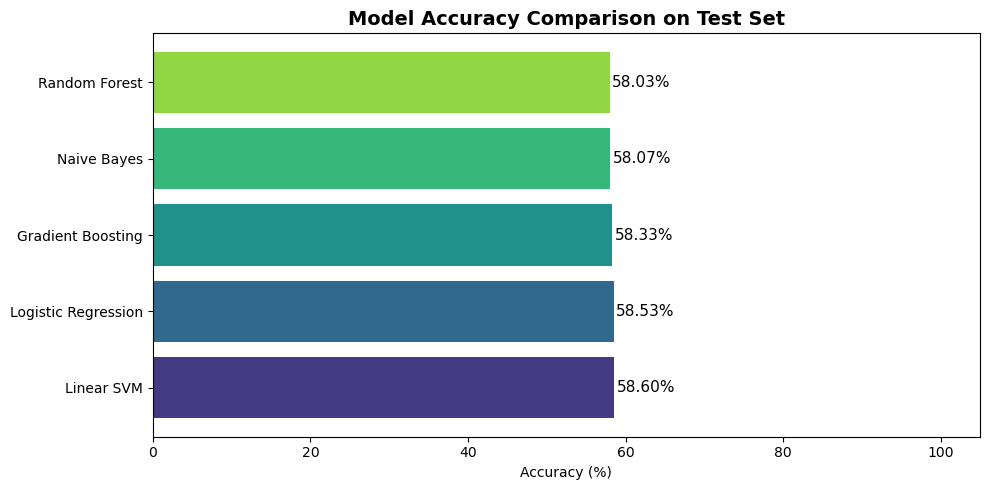

In [9]:
# Bar chart — accuracy comparison
fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette('viridis', len(summary))
bars = ax.barh(summary['Model'], summary['Accuracy (%)'], color=colors)

ax.set_xlabel('Accuracy (%)')
ax.set_title('Model Accuracy Comparison on Test Set', fontsize=14, fontweight='bold')
ax.set_xlim(0, 105)

for bar, val in zip(bars, summary['Accuracy (%)']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=11)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. 🔎 Detailed Report — Best Model

In [10]:
best_name  = summary.iloc[0]['Model']
best_preds = results[best_name]['y_pred']

print(f'🏆  Best model: {best_name}\n')
print(classification_report(
    y_test, best_preds,
    target_names=le.classes_
))

🏆  Best model: Linear SVM

                     precision    recall  f1-score   support

 account_block_scam       0.22      0.16      0.19       154
             benign       1.00      1.00      1.00      1364
fake_payment_portal       0.22      0.19      0.20       311
      impersonation       0.24      0.28      0.26       390
           kyc_scam       0.26      0.28      0.27       398
      phishing_link       0.25      0.23      0.24       383

           accuracy                           0.59      3000
          macro avg       0.36      0.36      0.36      3000
       weighted avg       0.59      0.59      0.59      3000



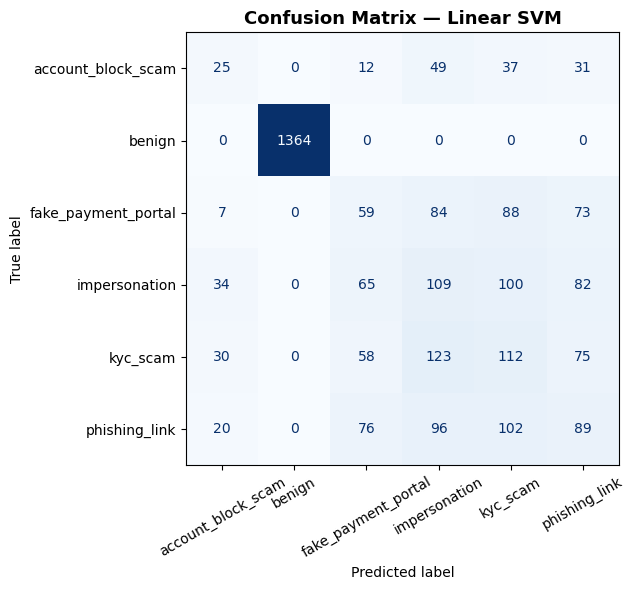

In [11]:
# Confusion matrix — best model
cm = confusion_matrix(y_test, best_preds)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=30)
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. 🔎 Per-Class Performance — All Models

Per-Class F1 Scores:
                     account_block_scam  benign  fake_payment_portal  impersonation  kyc_scam  phishing_link
Model                                                                                                       
Logistic Regression               0.174     1.0                0.203          0.256     0.269          0.241
Naive Bayes                       0.303     1.0                0.304          0.144     0.207          0.175
Linear SVM                        0.185     1.0                0.203          0.256     0.268          0.243
Random Forest                     0.125     1.0                0.185          0.266     0.230          0.256
Gradient Boosting                 0.159     1.0                0.180          0.271     0.230          0.267


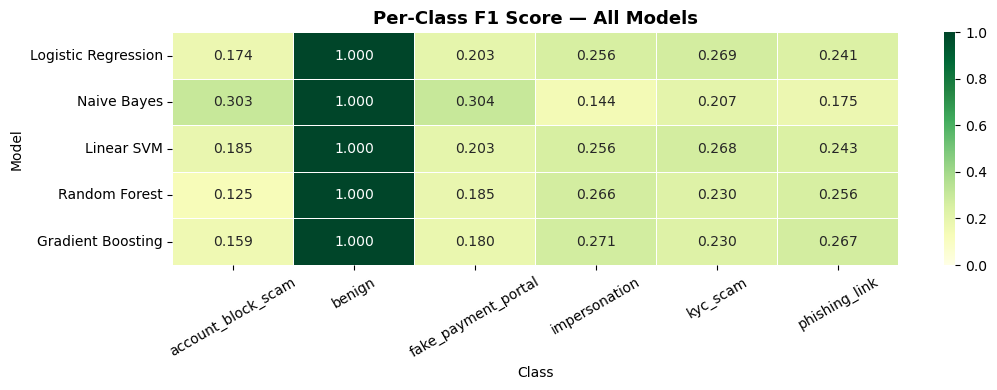

In [12]:
from sklearn.metrics import f1_score

f1_rows = []
for name, v in results.items():
    f1s = f1_score(y_test, v['y_pred'], average=None, labels=list(range(len(le.classes_))))
    row = {'Model': name}
    for cls, score in zip(le.classes_, f1s):
        row[cls] = round(score, 3)
    f1_rows.append(row)

f1_df = pd.DataFrame(f1_rows).set_index('Model')
print('Per-Class F1 Scores:')
print(f1_df.to_string())

# Heatmap
fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(f1_df, annot=True, fmt='.3f', cmap='YlGn',
            vmin=0, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Per-Class F1 Score — All Models', fontsize=13, fontweight='bold')
ax.set_xlabel('Class')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. 🔮 Predict on New Messages

In [13]:
def predict_message(text, model_name='Linear SVM'):
    """Predict the scam category of a single SMS message."""
    model  = results[model_name]['model']
    cleaned = clean_text(text)
    vec    = tfidf.transform([cleaned])
    pred   = model.predict(vec)
    label  = le.inverse_transform(pred)[0]
    return label

# Demo predictions
demo_messages = [
    "Your KYC has expired. Update immediately to avoid account block: http://kyc-update.xyz",
    "Your water bill for October is Rs. 450. Last date 30th Nov. Pay at nearest center.",
    "URGENT: Transaction of Rs.15000 debited from your account. Not done by you? Click here.",
    "Congratulations! You have won a lucky draw. Claim your prize by visiting our portal.",
]

print(f'Predictions using: {best_name}\n')
print(f'{"Message":60s}  |  Prediction')
print('-' * 85)
for msg in demo_messages:
    pred = predict_message(msg, best_name)
    print(f'{msg[:60]:60s}  |  {pred}')

Predictions using: Linear SVM

Message                                                       |  Prediction
-------------------------------------------------------------------------------------
Your KYC has expired. Update immediately to avoid account bl  |  phishing_link
Your water bill for October is Rs. 450. Last date 30th Nov.   |  benign
URGENT: Transaction of Rs.15000 debited from your account. N  |  benign
Congratulations! You have won a lucky draw. Claim your prize  |  benign


## 10. 💾 Save the Best Model

In [14]:
import joblib

joblib.dump(results[best_name]['model'], 'best_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
joblib.dump(le,    'label_encoder.pkl')

print(f'✅  Saved:')
print('   • best_model.pkl')
print('   • tfidf_vectorizer.pkl')
print('   • label_encoder.pkl')

# --- How to reload later ---
# model  = joblib.load('best_model.pkl')
# tfidf  = joblib.load('tfidf_vectorizer.pkl')
# le     = joblib.load('label_encoder.pkl')

✅  Saved:
   • best_model.pkl
   • tfidf_vectorizer.pkl
   • label_encoder.pkl


## 11. 📝 Final Summary

In [15]:
print('=' * 55)
print('           SMS SCAM CLASSIFICATION — SUMMARY')
print('=' * 55)
print(f'  Train samples : {len(train_df):,}')
print(f'  Test  samples : {len(test_df):,}')
print(f'  Classes       : {len(le.classes_)}')
print(f'  TF-IDF vocab  : {X_train.shape[1]:,} features')
print()
print('  Model Ranking:')
for _, row in summary.iterrows():
    marker = '🥇' if _ == 0 else ('🥈' if _ == 1 else '🥉' if _ == 2 else '  ')
    print(f'  {marker} {row["Model"]:25s} {row["Accuracy (%)"]:5.2f}%')
print()
print(f'  Best model    : {best_name}')
print(f'  Best accuracy : {summary.iloc[0]["Accuracy (%)"]:.2f}%')
print('=' * 55)

           SMS SCAM CLASSIFICATION — SUMMARY
  Train samples : 7,000
  Test  samples : 3,000
  Classes       : 6
  TF-IDF vocab  : 2,040 features

  Model Ranking:
  🥇 Linear SVM                58.60%
  🥈 Logistic Regression       58.53%
  🥉 Gradient Boosting         58.33%
     Naive Bayes               58.07%
     Random Forest             58.03%

  Best model    : Linear SVM
  Best accuracy : 58.60%
